Missing values before drop: 0
Missing values after drop:  0
Using 9 features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'symmetry_mean', 'fractal_dimension_mean']
Saved refined dataset to data_refined.csv


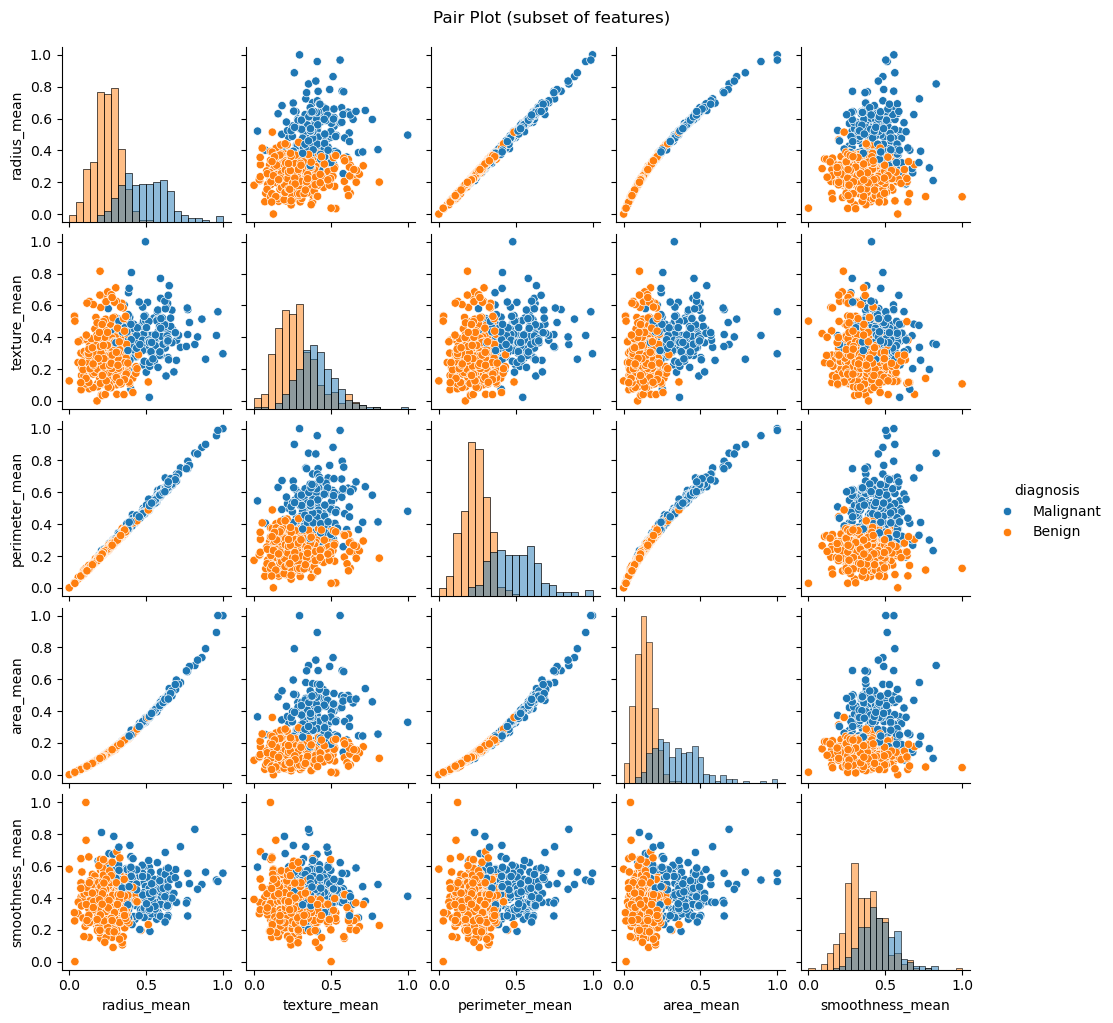

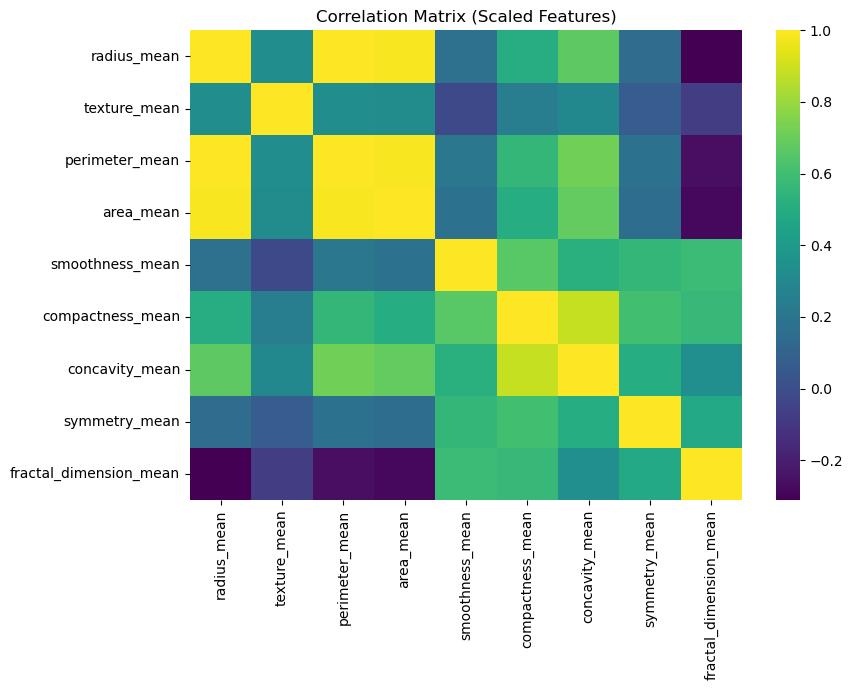

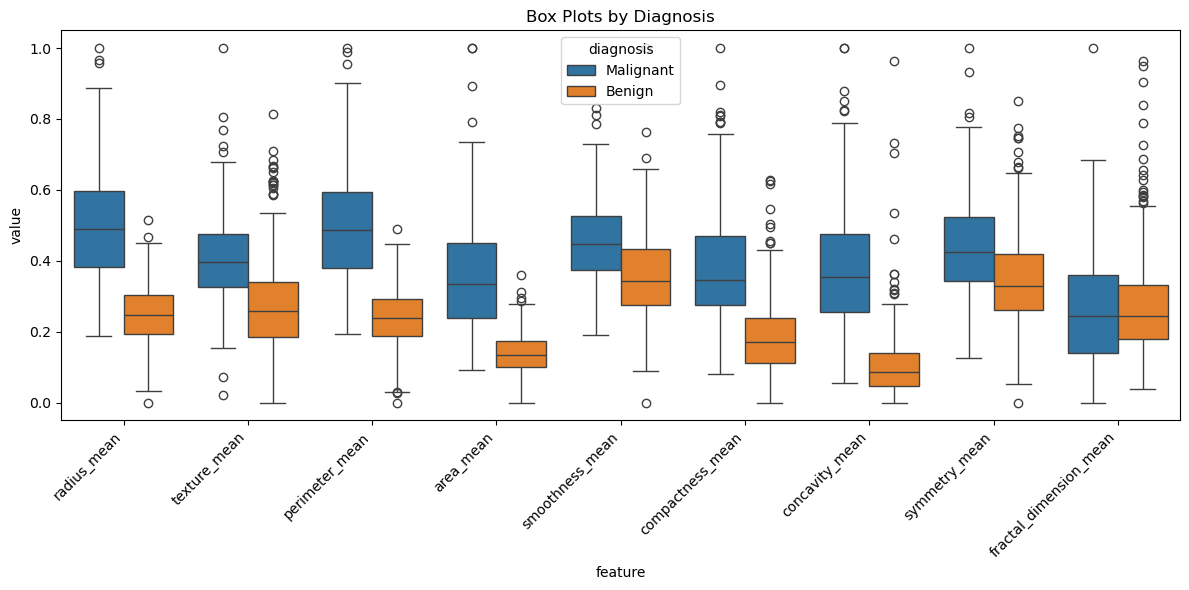

Done


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df = pd.read_csv("data.csv")

for col in ["Unnamed: 32", "unnamed: 32", "Unnamed:32"]:
    if col in df.columns:
        df = df.drop(columns=[col])

missing_before = df.isna().sum().sum()
df = df.dropna()
missing_after = df.isna().sum().sum()

print(f"Missing values before drop: {missing_before}")
print(f"Missing values after drop:  {missing_after}")

target_col = "diagnosis"
candidate_features = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean",
    "fractal_dimension_mean"
]
drop_cols = [c for c in ["id"] if c in df.columns]
df = df.drop(columns=drop_cols)

kept = [c for c in candidate_features if c in df.columns]
cols = [target_col] + kept
df = df[cols].copy()

print(f"Using {len(kept)} features: {kept}")

le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])

X = df[kept].copy()
y = df[target_col].copy()

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_imputed)

df_refined = pd.DataFrame(X_scaled, columns=kept)
df_refined[target_col] = y.values

out_path = "data_refined.csv"
df_refined.to_csv(out_path, index=False)
print(f"Saved refined dataset to {out_path}")

pairplot_features = kept[:5]
df_pair = df_refined[pairplot_features + [target_col]].copy()
df_pair[target_col] = df_pair[target_col].map({0: "Benign", 1: "Malignant"})

sns.pairplot(df_pair, hue=target_col, diag_kind="hist", height=2.0)
plt.suptitle("Pair Plot (subset of features)", y=1.02)
plt.show()

corr = df_refined[kept].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Correlation Matrix (Scaled Features)")
plt.tight_layout()
plt.show()

df_long = df_refined.melt(id_vars=[target_col], value_vars=kept, var_name="feature", value_name="value")
df_long[target_col] = df_long[target_col].map({0: "Benign", 1: "Malignant"})

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_long, x="feature", y="value", hue=target_col)
plt.title("Box Plots by Diagnosis")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print("Done")

In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# --- 1. Load Data and Prepare Target Variable ---
df = pd.read_csv("data.csv")
# Load the Wisconsin Breast Cancer dataset (it already has 'M' and 'B' labels)
data = load_breast_cancer(as_frame=True)
df = data.frame

# The target variable is 'target', which is 0 (Malignant) and 1 (Benign) in scikit-learn.
# We'll map it to M/B for correlation calculation based on your prompt description.
# 0 -> 'M' (Malignant)
# 1 -> 'B' (Benign)
df['Diagnosed'] = df['target'].map({0: 'M', 1: 'B'})
target_column = 'Diagnosed'
feature_columns = data.feature_names

# Convert the categorical target ('M', 'B') into numerical (0, 1) for correlation calculation
# A LabelEncoder is used here to transform 'M' and 'B' to 0 and 1, which allows for
# Pearson correlation with the numeric features.
le = LabelEncoder()
df['target_numeric'] = le.fit_transform(df[target_column])

# --- 2. Calculate Feature-Target Correlation ---
print("📊 Step 2: Calculating Feature-Target Correlation...")

# Calculate the absolute Pearson correlation between each feature and the numeric target
correlations = df[feature_columns].corrwith(df['target_numeric']).abs().sort_values(ascending=False)

# --- 3. Feature Selection based on Correlation Limit ---

# Define the minimum correlation threshold
# Features with an absolute correlation below this value will be excluded.
# This threshold is a hyperparameter you can tune. A common starting point is 0.5.
correlation_limit = 0.5

# Select features that are highly correlated with the target label
important_features = correlations[correlations > correlation_limit].index.tolist()

print(f"\n--- Feature Correlation Analysis ---")
print(f"**Correlation Limit Set:** > {correlation_limit}")
print(f"**Total Features:** {len(feature_columns)}")
print(f"**Selected Features:** {len(important_features)}")
print("-" * 34)

# Output the list of important features
print("\n✅ **Output List of Important Feature Names:**")
for i, feature in enumerate(important_features):
    print(f"{i+1}. {feature} (Corr: {correlations[feature]:.4f})")
print("-" * 34)

# --- 4. Decision Tree Training with Selected Features ---
print("\n🌳 Step 4: Training Decision Tree with Selected Features...")

# Prepare data for training
X = df[important_features]
y = df['target'] # Use the original 0/1 target for the decision tree

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Evaluate the model
accuracy = dt_classifier.score(X_test, y_test)
print(f"**Decision Tree Accuracy (with selected features):** {accuracy:.4f}")

# Optional: Visualize the importance the DT assigned to the selected features
print("\n**Decision Tree Feature Importance (based on Gini/Entropy reduction):**")
dt_feature_importances = pd.Series(dt_classifier.feature_importances_, index=important_features)
print(dt_feature_importances.sort_values(ascending=False))

📊 Step 2: Calculating Feature-Target Correlation...

--- Feature Correlation Analysis ---
**Correlation Limit Set:** > 0.5
**Total Features:** 30
**Selected Features:** 15
----------------------------------

✅ **Output List of Important Feature Names:**
1. worst concave points (Corr: 0.7936)
2. worst perimeter (Corr: 0.7829)
3. mean concave points (Corr: 0.7766)
4. worst radius (Corr: 0.7765)
5. mean perimeter (Corr: 0.7426)
6. worst area (Corr: 0.7338)
7. mean radius (Corr: 0.7300)
8. mean area (Corr: 0.7090)
9. mean concavity (Corr: 0.6964)
10. worst concavity (Corr: 0.6596)
11. mean compactness (Corr: 0.5965)
12. worst compactness (Corr: 0.5910)
13. radius error (Corr: 0.5671)
14. perimeter error (Corr: 0.5561)
15. area error (Corr: 0.5482)
----------------------------------

🌳 Step 4: Training Decision Tree with Selected Features...
**Decision Tree Accuracy (with selected features):** 0.9357

**Decision Tree Feature Importance (based on Gini/Entropy reduction):**
worst radius      